In [1]:
import csv

csv_path = "kegiatan/sensus-ekonomi-2026/2026/Realisasi - 6104.csv"
with open(csv_path, mode='r', encoding='utf-8-sig') as f:
    reader = csv.DictReader(f)
    rows = list(reader)

print("=== DATA REALISASI SE-2026 KAB. MEMPAWAH ===")
print(f"Total baris data: {len(rows)}")
if rows:
    print("Kolom yang tersedia:", list(rows[0].keys()))


=== DATA REALISASI SE-2026 KAB. MEMPAWAH ===
Total baris data: 31716
Kolom yang tersedia: ['No', 'Kab/Kota', 'Kode Wilayah (Sub-SLS)', 'Username Petugas', 'Email Petugas', 'Role', 'Total Target', 'DRAFT', 'OPEN', 'SUBMITTED RESPONDENT', 'SUBMITTED BY Pencacah', 'APPROVED BY Pengawas', 'REJECTED BY Pengawas', 'REVOKED BY Pengawas', 'EDITED BY Pengawas', '', 'Total Submit PPL', 'Total Submit Seluruh SLS per Petugas', 'Nama PJ', 'Target', '14,29%', 'Ranking', 'Status Target', 'Nama PJ Kuda']


In [2]:
# Analisis ringkas progres Mempawah vs Kabupaten Lain
mempawah_rows = [r for r in rows if r.get('Kab/Kota', '').strip() == 'MEMPAWAH']

total_target = sum(int(r.get('Total Target', 0) or 0) for r in mempawah_rows)
total_draft = sum(int(r.get('DRAFT', 0) or 0) for r in mempawah_rows)
total_submitted = sum(int(r.get('SUBMITTED BY Pencacah', 0) or 0) for r in mempawah_rows)
total_approved = sum(int(r.get('APPROVED BY Pengawas', 0) or 0) for r in mempawah_rows)

completed = total_submitted + total_approved
worked = completed + total_draft

print("=== RINGKASAN AGREGAT MEMPAWAH ===")
print(f"Total Target    : {total_target} unit")
if total_target > 0:
    print(f"Worked Rate     : {worked / total_target * 100:.2f}% ({worked} unit)")
    print(f"Completed Rate  : {completed / total_target * 100:.2f}% ({completed} unit)")
else:
    print("Target tidak ditemukan.")


=== RINGKASAN AGREGAT MEMPAWAH ===
Total Target    : 111017 unit
Worked Rate     : 20.60% (22864 unit)
Completed Rate  : 14.27% (15837 unit)


Grafik visualisasi sukses dibuat dan disimpan di scratch/mempawah_progress.png


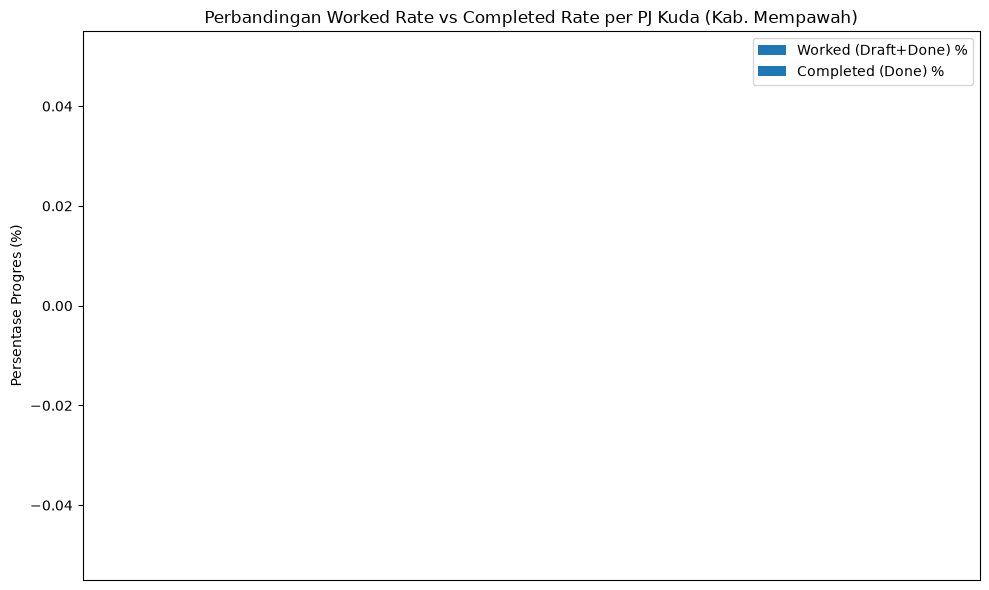

In [3]:
# Visualisasi Progres per PJ Kuda di Kabupaten Mempawah
import matplotlib.pyplot as plt

# Agregasi data per PJ Kuda
pj_stats = {}
for r in rows:
    if r.get('Kab/Kota', '').strip() == 'MEMPAWAH':
        pj = r.get('Nama PJ Kuda', r.get('Nama PJ', '')).strip()
        if not pj:
            continue
        target = int(r.get('Total Target', 0) or 0)
        draft = int(r.get('DRAFT', 0) or 0)
        submitted = int(r.get('SUBMITTED BY Pencacah', 0) or 0)
        approved = int(r.get('APPROVED BY Pengawas', 0) or 0)
        completed = submitted + approved
        worked = completed + draft
        
        pj_stats.setdefault(pj, {'target': 0, 'worked': 0, 'completed': 0})
        pj_stats[pj]['target'] += target
        pj_stats[pj]['worked'] += worked
        pj_stats[pj]['completed'] += completed

# Buat visualisasi
pj_names = sorted(list(pj_stats.keys()))
targets = [pj_stats[pj]['target'] for pj in pj_names]
worked_rates = [pj_stats[pj]['worked'] / pj_stats[pj]['target'] * 100 if pj_stats[pj]['target'] > 0 else 0 for pj in pj_names]
done_rates = [pj_stats[pj]['completed'] / pj_stats[pj]['target'] * 100 if pj_stats[pj]['target'] > 0 else 0 for pj in pj_names]

fig, ax = plt.subplots(figsize=(10, 6))
x = range(len(pj_names))
width = 0.35

ax.bar([i - width/2 for i in x], worked_rates, width, label='Worked (Draft+Done) %', color='#FFC107')
ax.bar([i + width/2 for i in x], done_rates, width, label='Completed (Done) %', color='#4CAF50')

ax.set_ylabel('Persentase Progres (%)')
ax.set_title('Perbandingan Worked Rate vs Completed Rate per PJ Kuda (Kab. Mempawah)')
ax.set_xticks(x)
ax.set_xticklabels(pj_names, rotation=45, ha='right')
ax.legend()
plt.tight_layout()

# Simpan grafik
plt.savefig('scratch/mempawah_progress.png')
print("Grafik visualisasi sukses dibuat dan disimpan di scratch/mempawah_progress.png")
plt.show()
